# Amazon Sales Exploratory Data Analysis (EDA)

Этот ноутбук содержит полноценный разведочный анализ данных (EDA) датасета продаж Amazon. В нём реализованы лучшие практики очистки данных и визуализации, необходимые для работы Data Analyst / ML Engineer.

## 1. Загрузка библиотек и данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения графиков
%matplotlib inline
sns.set_theme(style="whitegrid")

# Загрузка данных (файл лежит в той же папке)
df = pd.read_csv('amazon.csv')
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Размер данных: 1465 строк, 16 столбцов


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## 2. Очистка данных (Data Cleaning)

Главная проблема исходного датасета — числа, записанные в виде строк со спецсимволами (рупии `₹`, запятые `,`, проценты `%`). Мы должны очистить их и привести к числовым типам (`float` / `int`).

In [2]:
df_cleaned = df.copy()

def clean_currency(x):
    if isinstance(x, str):
        x = x.replace('₹', '').replace(',', '').strip()
    return pd.to_numeric(x, errors='coerce')

def clean_percentage(x):
    if isinstance(x, str):
        x = x.replace('%', '').strip()
    return pd.to_numeric(x, errors='coerce')

def clean_numeric_string(x):
    if isinstance(x, str):
        x = x.replace(',', '').strip()
    return pd.to_numeric(x, errors='coerce')

# 1. Очистка цен
df_cleaned['discounted_price'] = df_cleaned['discounted_price'].apply(clean_currency)
df_cleaned['actual_price'] = df_cleaned['actual_price'].apply(clean_currency)

# 2. Очистка процентов скидки
df_cleaned['discount_percentage'] = df_cleaned['discount_percentage'].apply(clean_percentage)

# 3. Очистка счетчика рейтингов
df_cleaned['rating_count'] = df_cleaned['rating_count'].apply(clean_numeric_string)

# 4. Очистка рейтинга (в данных есть мусорные значения типа '|')
df_cleaned['rating'] = pd.to_numeric(df_cleaned['rating'], errors='coerce')

print("Типы данных после очистки:")
print(df_cleaned[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].dtypes)

print("\nКоличество пропусков (NaN) после конвертации:")
print(df_cleaned.isnull().sum()[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']])

Типы данных после очистки:
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
dtype: object

Количество пропусков (NaN) после конвертации:
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
dtype: int64


## 3. Разведочный анализ данных (EDA)

Теперь мы можем строить осмысленные графики.

### 3.1 Распределение цен и скидок (Univariate Analysis)

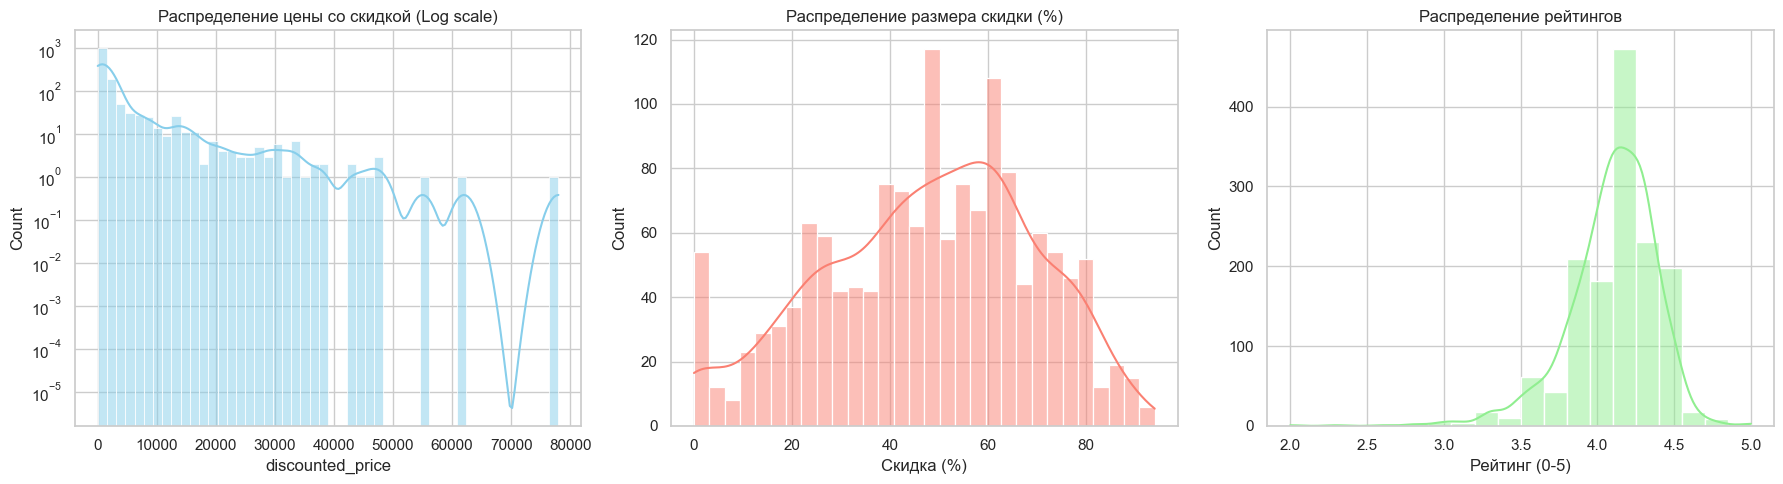

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_cleaned['discounted_price'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение цены со скидкой (Log scale)')
axes[0].set_yscale('log') # Логарифмическая шкала, так как есть очень дорогие товары

sns.histplot(df_cleaned['discount_percentage'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Распределение размера скидки (%)')
axes[1].set_xlabel('Скидка (%)')

sns.histplot(df_cleaned['rating'].dropna(), bins=20, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Распределение рейтингов')
axes[2].set_xlabel('Рейтинг (0-5)')

plt.tight_layout()
plt.show()

### 3.2 Взаимосвязь между переменными (Bivariate Analysis)

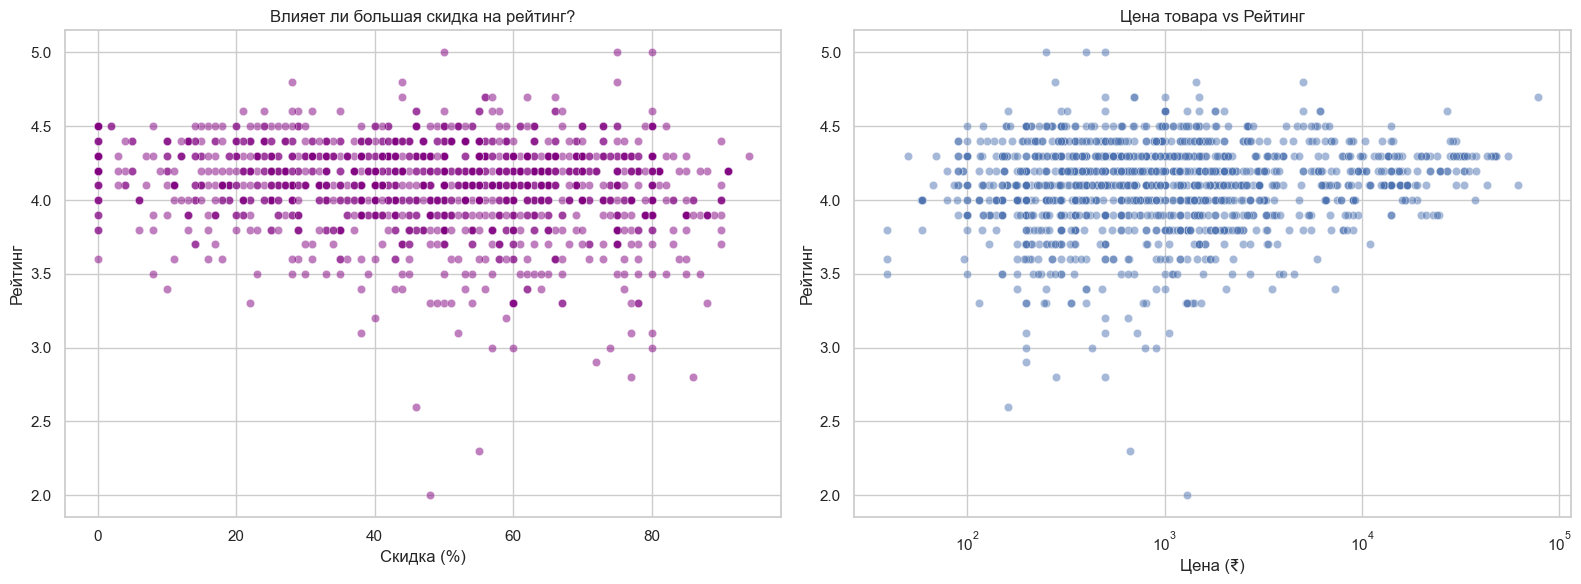

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_cleaned, x='discount_percentage', y='rating', alpha=0.5, ax=axes[0], color='purple')
axes[0].set_title('Влияет ли большая скидка на рейтинг?')
axes[0].set_xlabel('Скидка (%)')
axes[0].set_ylabel('Рейтинг')

sns.scatterplot(data=df_cleaned, x='discounted_price', y='rating', alpha=0.5, ax=axes[1])
axes[1].set_title('Цена товара vs Рейтинг')
axes[1].set_xlabel('Цена (₹)')
axes[1].set_ylabel('Рейтинг')
axes[1].set_xscale('log') # Логарифмическая шкала для цены

plt.tight_layout()
plt.show()

### 3.3 Анализ категорий (Categorical Analysis)
В столбце `category` хранится полное дерево категорий (разделитель `|`). Давайте выделим главную (первую) категорию и посмотрим статистику по ней.

C:\Users\Asus\AppData\Local\Temp\ipykernel_15608\3108946228.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')


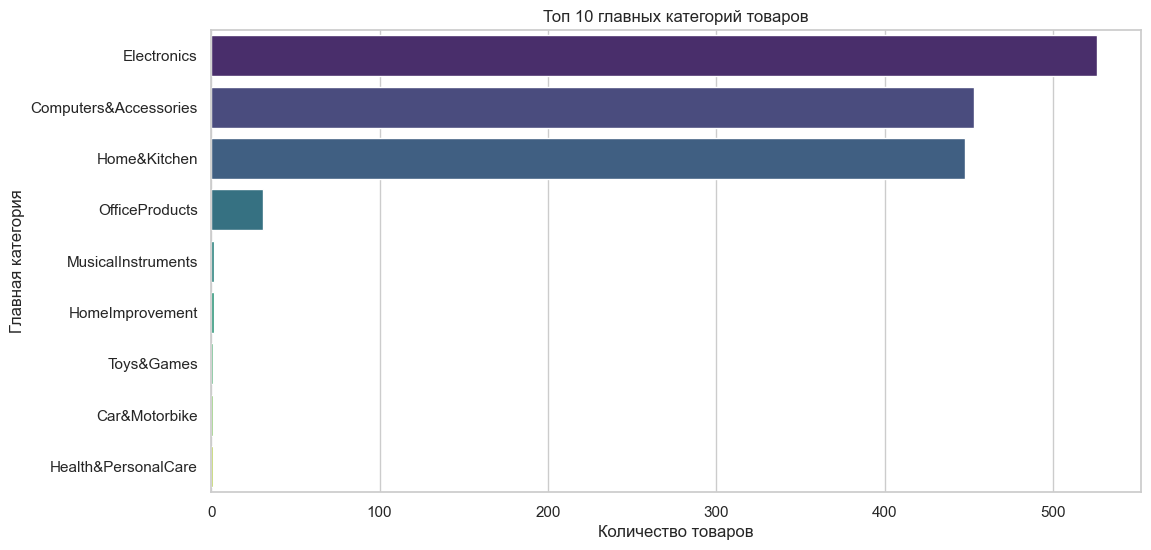

In [5]:
# Извлекаем главную категорию
df_cleaned['main_category'] = df_cleaned['category'].apply(lambda x: str(x).split('|')[0] if pd.notnull(x) else 'Unknown')

# Считаем популярность категорий
category_counts = df_cleaned['main_category'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')
plt.title('Топ 10 главных категорий товаров')
plt.xlabel('Количество товаров')
plt.ylabel('Главная категория')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_15608\1134621950.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_stats.head(10), y='main_category', x='rating', palette='magma')


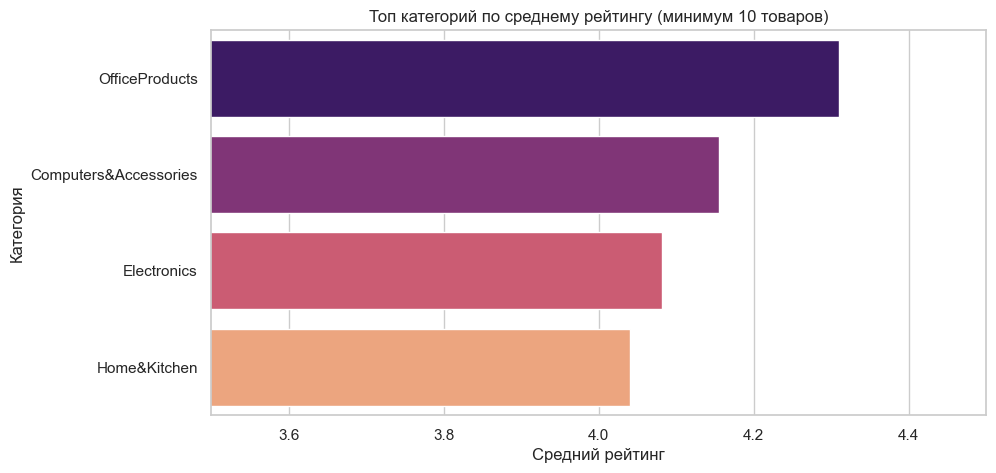

In [6]:
# Средний рейтинг по главным категориям
cat_stats = df_cleaned.groupby('main_category').agg({'rating': 'mean', 'discount_percentage': 'mean', 'product_id': 'count'}).reset_index()
cat_stats = cat_stats[cat_stats['product_id'] > 10] # Отсеиваем слишком редкие категории для честной статистики
cat_stats = cat_stats.sort_values(by='rating', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=cat_stats.head(10), y='main_category', x='rating', palette='magma')
plt.title('Топ категорий по среднему рейтингу (минимум 10 товаров)')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.xlim(3.5, 4.5)
plt.show()

## 4. Корреляционная матрица

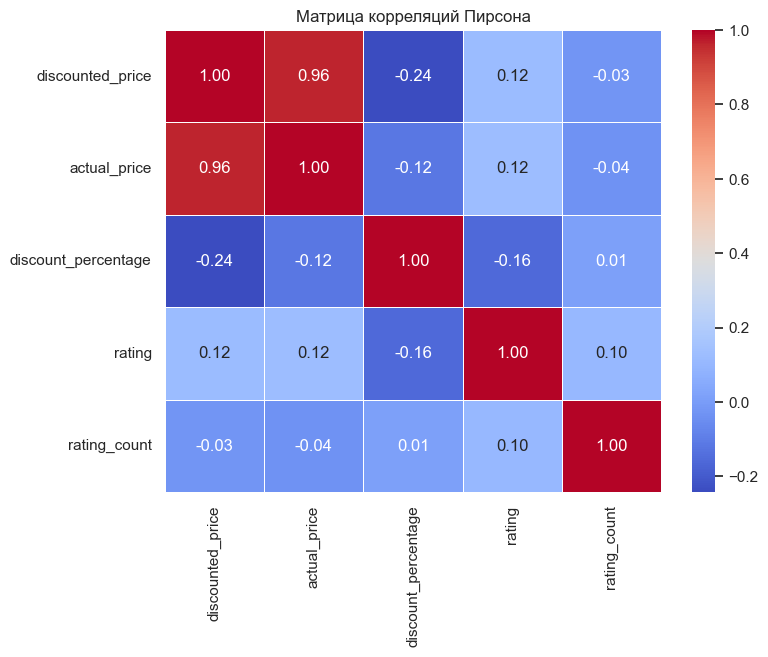

In [7]:
plt.figure(figsize=(8, 6))
numeric_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']
corr_matrix = df_cleaned[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляций Пирсона')
plt.show()